In [1]:
#0
import pandas as pd

# Reemplaza 'tu_archivo.dta' por el nombre exacto de tu archivo
df_05 = pd.read_stata('usu_individual_t105.dta')

# Reemplaza 'tu_archivo.dta' por el nombre exacto de tu archivo
df_25 = pd.read_excel('usu_individual_T125.xlsx')

# Muestra las primeras filas para verificar
df_05.head()
df_25.head()

print(df_05.head())
print(df_25.head())

     CODUSU  nro_hogar componente  h15    ano4       trimestre  \
0  125098          1.0        1.0   Sí  2005.0  1er. Trimestre   
1  125188          1.0        1.0   Sí  2005.0  1er. Trimestre   
2  125188          1.0        2.0   Sí  2005.0  1er. Trimestre   
3  125188          1.0        3.0  0.0  2005.0  1er. Trimestre   
4  125242          1.0        1.0   Sí  2005.0  1er. Trimestre   

              region mas_500              aglomerado  pondera  ... deccfr  \
0  Gran Buenos Aires       S  Ciudad de Buenos Aires   1017.0  ...     08   
1  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
2  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
3  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
4  Gran Buenos Aires       S  Ciudad de Buenos Aires   1103.0  ...     09   

  ideccfr rdeccfr gdeccfr pdeccfr adeccfr pj1_1 pj2_1 pj3_1 idimpp  
0              07      08              05   0.0   0.0   0.0  00000  
1 

In [4]:
#0 Junto ambas bases
import pandas as pd

# Reemplaza 'tu_archivo.dta' por el nombre exacto de tu archivo
df_05 = pd.read_stata('usu_individual_t105.dta')

# Reemplaza 'tu_archivo.dta' por el nombre exacto de tu archivo
df_25 = pd.read_excel('usu_individual_T125.xlsx')


#Una vez visto el formato de cada variable, pasamos el formato de las de 2005, igual al de 2025.
import pandas as pd
import numpy as np
from pandas.api.types import is_integer_dtype, is_float_dtype


# 0) Copia y normalizo nombres

df2005 = df_05.copy()
df2025 = df_25.copy()

# renombro columnas de 2005 a MAYÚSCULAS para alinearlas con 2025
ren_2005 = {c: c.upper() for c in df2005.columns}
df2005 = df2005.rename(columns=ren_2005)


# 1) dtypes objetivo (2025)

target_dtypes = df2025.dtypes  #yo quiero todo igual al 2025.

# columnas comunes (por nombre ya en mayúsculas)
comunes = sorted(set(df2005.columns) & set(df2025.columns))


# 2) Mapeos especiales (texto a códigos)

SPECIAL_MAPS = {
    "CH04": {  # sexo: texto a 1/2
        "1": 1, "varon": 1, "varón": 1, "hombre": 1, "m": 1, "masculino": 1,
        "2": 2, "mujer": 2, "f": 2, "femenino": 2
    },
}

def apply_special_map(series: pd.Series, col: str) -> pd.Series:
    if col not in SPECIAL_MAPS:
        return series
    # normalizo a string-lower y mapeo
    m = SPECIAL_MAPS[col]
    s = series.astype("string").str.strip().str.lower()
    return s.map(m)# 3) Conversión columna a columna

def convert_to_target(s: pd.Series, target_dtype) -> pd.Series:
    """
    Convierte s al dtype de 2025:
      - int64  -> numérico y luego Int64 (si no hay NaN, baja a int64)
      - float64-> numérico float
      - object -> a object/string
      - category en 2005 se elimina (paso intermedio a object)
    """
    # sacar 'category' si viene así de 2005
    if str(s.dtype) == "category":
        s = s.astype("object")

    # int objetivo
    if is_integer_dtype(target_dtype):
        s_num = pd.to_numeric(s, errors="coerce")
        out = s_num.round().astype("Int64")
        # si no hay NA, convierto a numpy int64 puro (opcional)
        if out.isna().sum() == 0:
            out = out.astype("int64")
        return out

    # float objetivo
    if is_float_dtype(target_dtype):
        return pd.to_numeric(s, errors="coerce").astype("float64")

    # object objetivo
    return s.astype("object")

# hago una copia donde ir dejando las columnas ya convertidas
df2005_conv = df2005.copy()

log = []  # para ver qué se hizo

for col in comunes:
    tgt = target_dtypes[col]

    # 1) mapeo especial si aplica (por ej. CH04)
    mapped = apply_special_map(df2005_conv[col], col)
    if col in SPECIAL_MAPS:
        # si hubo mapeo, reemplazo donde haya valor mapeado
        df2005_conv[col] = mapped.where(mapped.notna(), df2005_conv[col])

    # 2) convierto al dtype de 2025
    before = str(df2005_conv[col].dtype)
    df2005_conv[col] = convert_to_target(df2005_conv[col], tgt)
    after = str(df2005_conv[col].dtype)

    log.append((col, before, str(tgt), after))


# 4) Resumen de el pase de variable

resumen = pd.DataFrame(log, columns=["columna", "dtype_2005_origen", "dtype_2025_objetivo", "dtype_2005_final"])
resumen = resumen.sort_values("columna").reset_index(drop=True)

print("Conversión realizada sobre", len(comunes), "columnas comunes.")
display(resumen.head(20))

# df2005_conv es la  base de 2005 armonizada a los formatos de 2025
# (mismos nombres en MAYÚSCULA y dtypes compatibles con 2025)
#ahora que esto funciona, vamos a trabajr con:
#df 2005 = df2005_conv
#df 2025 = df_T125

Conversión realizada sobre 168 columnas comunes.


,columna,dtype_2005_origen,dtype_2025_objetivo,dtype_2005_final
0,ADECCFR,object,int64,int64
1,ADECIFR,object,int64,int64
2,ADECINDR,object,int64,int64
3,ADECOCUR,object,int64,Int64
4,AGLOMERADO,category,int64,Int64
5,ANO4,float64,int64,int64
6,CAT_INAC,category,int64,Int64
7,CAT_OCUP,category,int64,Int64
8,CH03,category,int64,Int64
9,CH04,int64,int64,int64


In [8]:
#5) Alinear columnas y juntar

# columnas únicas a cada dataframe
cols_2005_unicas = sorted(set(df2005_conv.columns) - set(comunes))
cols_2025_unicas = sorted(set(df2025.columns) - set(comunes))


# creo copias para no modificar los df originales
df2005_aligned = df2005_conv.copy()
df2025_aligned = df2025.copy()


# agrego columnas únicas de 2025 a 2005 (con NaN)
for col in cols_2025_unicas:
    df2005_aligned[col] = pd.NA  # o pd.NA o np.nan según el dtype

# agrego columnas únicas de 2005 a 2025 (con NaN)
for col in cols_2005_unicas:
    df2025_aligned[col] = pd.NA # o pd.NA o np.nan según el dtype


# reordeno columnas para que estén en el mismo orden
df2005_aligned = df2005_aligned[sorted(df2005_aligned.columns)]
df2025_aligned = df2025_aligned[sorted(df2025_aligned.columns)]


# verifico que tengan las mismas columnas y en el mismo orden
if not df2005_aligned.columns.equals(df2025_aligned.columns):
    print("Error: Las columnas no coinciden después de alinear.")
else:
    print("Columnas alineadas correctamente.")
    # concateno
    base_final = pd.concat([df2005_aligned, df2025_aligned], ignore_index=True)
    print("Bases concatenadas. Tamaño de base_final:", base_final.shape)

# Display a random sample of the final dataframe
display(base_final.sample(5))

Columnas alineadas correctamente.


/var/folders/gt/s4fbknnd2_ld7p8jjqmlyhxh0000gp/T/ipykernel_976/473170928.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_final = pd.concat([df2005_aligned, df2025_aligned], ignore_index=True)
/var/folders/gt/s4fbknnd2_ld7p8jjqmlyhxh0000gp/T/ipykernel_976/473170928.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_final = pd.concat([df2005_aligned, df2025_aligned], ignore_index=True)
/var/folders/gt/s4fbknnd2_ld7p8jjqmlyhxh0000gp/T/ipykernel_976/473170928.py:33: FutureWarning: T

Bases concatenadas. Tamaño de base_final: (92455, 243)


,ADECCFR,ADECIFR,ADECINDR,ADECOCUR,AGLOMERADO,ANO4,CAT_INAC,CAT_OCUP,CH03,CH04,...,V2_03_M,V2_M,V3_M,V4_M,V5_01_M,V5_02_M,V5_03_M,V5_M,V8_M,V9_M
59210,12,12,9,9,27,2025,0,3,1,1,...,0,NaN,0,0,0,0,0,NaN,0,0
84623,5,10,0,0,18,2025,3,0,3,2,...,0,NaN,0,0,0,0,0,NaN,0,0
61434,3,7,1,0,4,2025,0,3,3,2,...,0,NaN,0,0,100000,0,0,NaN,0,0
24519,2,3,6,6,<NA>,2005,0,<NA>,<NA>,1,...,<NA>,0.0,0,0,<NA>,<NA>,<NA>,0.0,0,0
14706,4,5,6,<NA>,<NA>,2005,<NA>,0,<NA>,1,...,<NA>,0.0,0,0,<NA>,<NA>,<NA>,0.0,0,0


/var/folders/gt/s4fbknnd2_ld7p8jjqmlyhxh0000gp/T/ipykernel_976/892618775.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_final["EDAD2"] = (base_final["CH06"] ** 2).astype("float64")


Text(0, 0.5, 'Frecuencia')

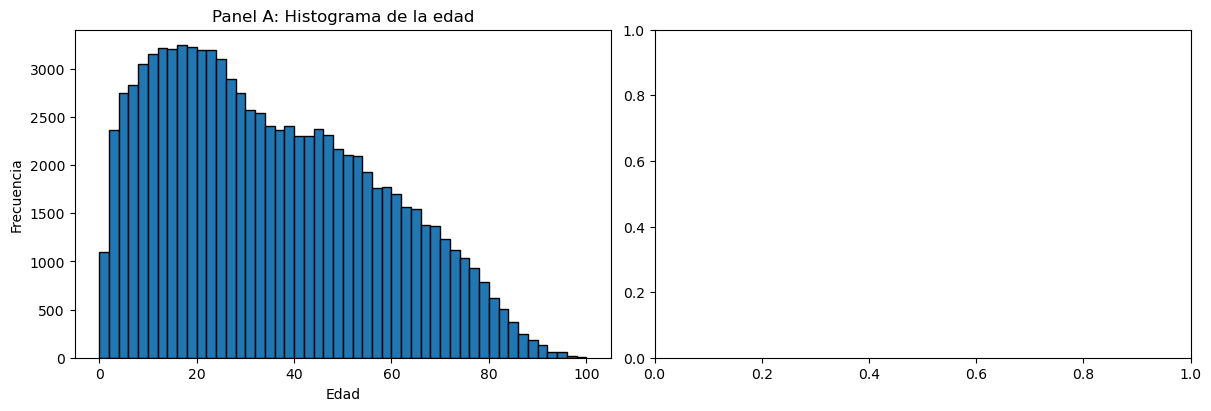

In [9]:
#1 Creo la variable edad2 y hago un histograma de su distribución

import matplotlib.pyplot as plt

base_final["CH06"] = pd.to_numeric(base_final["CH06"], errors="coerce")

# crear edad2
base_final["EDAD2"] = (base_final["CH06"] ** 2).astype("float64")

# opcional: defragmentar para evitar warnings futuros
base_final = base_final.copy()

# datos para el histograma
edad = base_final["CH06"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Panel A: histograma de edad
axes[0].hist(edad, bins=np.arange(0, 101, 2), edgecolor="black")
axes[0].set_title("Panel A: Histograma de la edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")


In [ ]:
#1 Inserto la construcción del Indicador de Pobreza del TP1

# Asegurar que ESTADO sea numérico (si quedó como texto "0", lo convierte)
base_final["ESTADO"] = pd.to_numeric(base_final["ESTADO"], errors="coerce")

# Ver si aparecen 0 o NaN
print("¿Hay 0 en ESTADO? ", (base_final["ESTADO"] == 0).any())
print("¿Hay NaN en ESTADO?", base_final["ESTADO"].isna().any())

# Conteo total de no respuesta (0 o NaN)
mask_no_resp = base_final["ESTADO"].isna() | (base_final["ESTADO"] == 0)
n_total = len(base_final)
n_no    = mask_no_resp.sum()
print(f"\nNo respondieron condición de actividad (0 o NaN): {n_no} de {n_total}  ({n_no/n_total:.1%})")

# Detalle por año
if "ANO4" in base_final.columns:
    resumen = (base_final.assign(no_resp=mask_no_resp)
                          .groupby("ANO4")["no_resp"]
                          .agg(no_resp="sum", total="size"))
    resumen["pct"] = 100 * resumen["no_resp"] / resumen["total"]
    print("\nPor año (2005 vs 2025):\n", resumen)


print(base_final["ESTADO"].value_counts(dropna=False).sort_index()) # Mirar los valores que tiene ESTADO

In [10]:
# Asegurar numérico
if "ITF" in base_final.columns:
    base_final["ITF"] = pd.to_numeric(base_final["ITF"], errors="coerce")
else:
    print("Warning: 'ITF' column not found in base_final.")


# respondieron ITF (1 si ITF>0 and not NaN; 0 if ITF==0 or NaN) ===
# Using base_final directly
base_final["respondio_ITF"] = np.where(base_final["ITF"].notna() & (base_final["ITF"] > 0), 1, 0).astype("int8")


#  Bases pedidas por consigna ===
respondieron  = base_final.query("respondio_ITF == 1").copy()
norespondieron = base_final.query("respondio_ITF == 0").copy()

# === Resúmenes útiles para el informe ===
# Respondieron vs no respondieron por año
if "ANO4" in base_final.columns:
    resumen_itf = (
        base_final.groupby(["ANO4","respondio_ITF"]).size()
          .unstack(fill_value=0)
          .rename(columns={0:"norespondieron_ITF", 1:"respondieron_ITF"})
          .reset_index()
    )
    resumen_itf["tasa_noresp"] = resumen_itf["norespondieron_ITF"] / (
        resumen_itf["norespondieron_ITF"] + resumen_itf["respondieron_ITF"]
    )


    print("Resumen ITF por año:")
    print(resumen_itf)
else:
    print("Warning: 'ANO4' column not found in base_final. Cannot group by year.")

Resumen ITF por año:
respondio_ITF  ANO4  norespondieron_ITF  respondieron_ITF  tasa_noresp
0              2005                 438             46592     0.009313
1              2025               12053             33372     0.265338


In [12]:
# Empiezo a usar la base de los que respondieron sobre sus ingresos

from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

adulto_equiv = pd.read_excel(fname)
adulto_equiv

def cargar_tabla_adulto_equiv_simple(path="tabla_adulto_equiv.xlsx", verbose=True):
    # Leer todo como string para no “romper” nada al principio
    raw = pd.read_excel(path, header=None, dtype=str)

    # 1) Detectar automáticamente la fila y las 3 columnas correctas: Edad | Mujeres | Varones
    hdr_row = None
    col_edad = col_muj = col_var = None
    for r in range(len(raw)):
        row = raw.iloc[r].astype(str).str.strip().str.lower()
        for c in range(len(row) - 2):
            a, b, d = row.iloc[c], row.iloc[c+1], row.iloc[c+2]
            if a == "edad" and "mujer" in b and ("varon" in d or "varón" in d):
                hdr_row, col_edad, col_muj, col_var = r, c, c+1, c+2
                break
        if hdr_row is not None:
            break

    if hdr_row is None:
        raise ValueError("No encontré encabezados 'Edad | Mujeres | Varones' en el archivo.")

    if verbose:
        print(f"Encabezado detectado en fila {hdr_row} | columnas: EDAD={col_edad}, MUJERES={col_muj}, VARONES={col_var}")

    # 2) Quedarnos con esas 3 columnas desde la fila siguiente
    tbl = raw.iloc[hdr_row+1:, [col_edad, col_muj, col_var]].copy()
    tbl.columns = ["EDAD", "MUJERES", "VARONES"]

    # 3) Limpiar EDAD (espacios raros) y pasar equivalencias a número (coma -> punto)
    tbl["EDAD"] = (tbl["EDAD"].fillna("")
                             .str.replace("\xa0", " ", regex=False)
                             .str.strip()
                             .str.replace(r"\s+", " ", regex=True))

    for c in ["MUJERES", "VARONES"]:
        s = tbl[c].fillna("").str.replace("\xa0", " ", regex=False).str.strip()
        s = s.str.replace(",", ".", regex=False)  # por si vienen con coma decimal
        tbl[c] = pd.to_numeric(s, errors="coerce")

    # 4) Quitar filas basura (todas NaN o textos tipo 'Ejemplos...', 'Fuente...')
    basura = tbl["EDAD"].str.lower().str.contains("ejemplo|fuente|indec", na=False)
    todo_nan = tbl[["MUJERES","VARONES"]].isna().all(axis=1)
    tbl = tbl[~(basura | todo_nan)].reset_index(drop=True)

    return tbl

# === USO ===
adulto_equiv = cargar_tabla_adulto_equiv_simple("tabla_adulto_equiv.xlsx")

# 1) quitar la cabecera repetida
mask_midheader = adulto_equiv["EDAD"].astype(str).str.strip().str.lower().eq("edad")

# 2) quitar filas “basura” donde MUJERES y VARONES son ambos NaN
mask_allnan = adulto_equiv[["MUJERES","VARONES"]].isna().all(axis=1)

adulto_equiv = adulto_equiv[~(mask_midheader | mask_allnan)].reset_index(drop=True)

print(adulto_equiv)

ModuleNotFoundError: No module named 'google.colab'